> Технический прогон 14.09.2026: все расчётные ячейки этого отчёта выполнены последовательно в чистом ядре на указанных в коде исходных результатах. FEM заново не решалась. Исполнение отчёта не повышает доказательный статус исходного исследования.

# 40.06 Карты чувствительности и подготовка анализа новых электродных комбинаций

Этот отчёт фиксирует реализацию [плана подготовки](40.06_Подготовка_анализа_новых_электродных_комбинаций.md) от 10.09.2026. Цель этапа — получить проверяемый переход от интегральной чувствительности компартментов к пространственным картам и контролируемым локальным изменениям, а также снять привязку расчёта к одной комбинации четырёх электродов.

**Статус:** вычислительный эксперимент на фиксированной дискретной модели; физическая и экспериментальная валидация не выполнены. Геометрия новых анатомических монтажей не задавалась. Проверяются существующие контакты и новые комбинации их токовых и измерительных ролей. Синтетическая проверка шести контактов проверяет программный интерфейс, а не анатомическую модель шестиэлектродной сборки.

## 1. Связь с исходным исследованием и происхождение данных

Исходными данными являются подготовленная EIDORS-модель и контактные матрицы серии [40.05](40.05_Чувствительность_ТТРКГ_к_проводимости_тканей.ipynb). Эта серия содержит 432 сочетания монтажа и состояния; исходные результаты сохранены неизменными. Используется геометрия Nix, полученная из КТ и ручной сегментации, с искусственными цилиндрическими участками рук. Вдох относится к состоянию исходной КТ. Проводимости действительные, скалярные, при 50 кГц; геометрия фиксирована.

В качестве принятого допущения сердце остаётся одной эффективной областью крови и миокарда. Отдельная доля крови из неё не выводится. Мягкотканный фон включает модельные руки; лёгкие рассматриваются совместно; проводимость костей в проверочных состояниях фиксирована. Производная по проводимости костей может быть вычислена математически, но не означает, что кости введены как пульсовой источник.

Смешанный монтаж 20/80 служит проверкой повторного использования полей: прямое и взаимное решения сохранены в отдельном контроле решателя. Для поверхностных кольцевых манжет 20/80 выполнено новое решение нескольких правых частей. Сохранены точные входные контрольные суммы и архивы использованного кода. Все данные этой серии находятся отдельно от исходного расчёта, в каталоге `output/exploratory/electrode_sensitivity_20260910`.

In [2]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'MATLAB_TRKG4_real_subjects/run_pipeline.m').is_file())
OUT=ROOT/'MATLAB_TRKG4_real_subjects/output/exploratory/electrode_sensitivity_20260910'
RUN=OUT/'pilot_combinations_verified'
CACHED=OUT/'pilot_cached'
CHECKS=OUT/'checks_combinations_final'
for folder in [RUN,CACHED]:
    completion=json.loads((folder/'completion.json').read_text(encoding='utf-8'))
    assert completion['status']=='completed_numerical_checks_passed'
    if (folder/'completion.sha256').exists():
        assert hashlib.sha256((folder/'completion.json').read_bytes()).hexdigest()==(folder/'completion.sha256').read_text().strip()
    for name,expected in completion['output_sha256'].items():
        with (folder/name).open('rb') as f:assert hashlib.file_digest(f,'sha256').hexdigest()==expected
check_manifest=json.loads((CHECKS/'checks.json').read_text(encoding='utf-8'))
assert check_manifest['status']=='passed'
for name,expected in check_manifest['output_sha256'].items():
    with (CHECKS/name).open('rb') as f:assert hashlib.file_digest(f,'sha256').hexdigest()==expected
verification=pd.read_csv(CHECKS/'verification.csv')
assert verification.passed.all()
channels=pd.read_csv(RUN/'channel_results.csv')
summary=pd.read_csv(RUN/'compartment_maps.csv')
probes=pd.read_csv(CHECKS/'equal_volume_probes.csv')
fd=pd.read_csv(CHECKS/'local_finite_differences.csv')
with np.load(RUN/'map_geometry.npz') as f:geometry={k:f[k] for k in f.files}
labels={'soft_tissue':'Мягкотканный фон','lungs':'Лёгкие','heart':'Сердечная область','bones':'Кости'}
channel_names={'standard':'Основная','adjacent':'Соседние пары','cross':'Перекрёстная'}
pd.set_option('display.max_colwidth',None)
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
display(Markdown(f'Загружены **{len(channels)} комбинации ролей**, карты **{len(geometry["volume_m3"]):,} элементов** и **{len(verification)} численных сопоставлений**. Исходные файлы прошли проверку контрольных сумм.'))

Загружены **3 комбинации ролей**, карты **4,358,825 элементов** и **20 численных сопоставлений**. Исходные файлы прошли проверку контрольных сумм.

## 2. Разделение геометрии, канала, состояния и возмущения

Под монтажом понимается физически присутствующий набор контактных поверхностей. Канал задаёт два вектора весов: токовый и измерительный. Каждое исходное состояние содержит проводимости всех параметров. Возмущение задаётся отдельно от исходного состояния и может охватывать весь компартмент или локальную область.

Токовый вектор нормирован на 1 А: положительные веса в сумме равны 1, отрицательные — −1. Измерительный вектор имеет такую же нормировку весов и задаёт разность взвешенных потенциалов. Это нормировка линейного расчёта, а не предложение подавать такой ток на человека. Для нескольких каналов одна матрица системы используется с несколькими правыми частями. Изменение токовых ролей не удаляет остальные физически присутствующие контакты полной электродной модели (CEM).

Ниже индексы E1–E4 соответствуют зафиксированному порядку контактов: наружный справа, внутренний справа, внутренний слева, наружный слева. В новом прогоне все четыре контакта являются поверхностными кольцевыми манжетами. Поперечные плоскости смешанного монтажа используются только в отдельной проверке исходного стандартного канала.

In [3]:
study=json.loads((OUT/'pilot_combinations.json').read_text(encoding='utf-8'))
table=[]
for c in study['montages'][0]['channels']:
    table.append({'Комбинация':channel_names[c['id']],'Токовые веса E1–E4':str(c['drive']),'Измерительные веса E1–E4':str(c['measure'])})
display(pd.DataFrame(table).style.hide(axis='index'))
base=[]
for param in study['parameters']:
    base.append({'Компартмент':{'soft':'Мягкотканный фон','heart':'Сердечная область','lung':'Лёгкие','bone':'Кости'}[param['id']],'Исходная проводимость, См/м':param['nominal_sigma'],'Фиксирован в серии': 'Да' if param['fixed'] else 'Нет'})
display(pd.DataFrame(base).style.hide(axis='index').format({'Исходная проводимость, См/м':'{:.9f}'}))
display(Markdown('В этой проверке используется одно исходное состояние. Проводимости в таблице приняты из опорного расчёта; они не являются независимо измеренными свойствами тканей. Локальные изменения задаются отдельно ниже.'))

Комбинация,Токовые веса E1–E4,Измерительные веса E1–E4
Основная,"[1, 0, 0, -1]","[0, 1, -1, 0]"
Соседние пары,"[1, -1, 0, 0]","[0, 0, 1, -1]"
Перекрёстная,"[1, 0, -1, 0]","[0, 1, 0, -1]"


Компартмент,"Исходная проводимость, См/м",Фиксирован в серии
Мягкотканный фон,0.211498103,Нет
Сердечная область,0.195435242,Нет
Лёгкие,0.057449143,Нет
Кости,0.020641911,Да


В этой проверке используется одно исходное состояние. Проводимости в таблице приняты из опорного расчёта; они не являются независимо измеренными свойствами тканей. Локальные изменения задаются отдельно ниже.

## 3. Поэлементная чувствительность и её плотность

Для линейного тетраэдра градиент потенциала постоянен внутри элемента. При полях, нормированных на прямой и взаимный ток, вычисляется

$$J_e=-V_e\nabla u_I\cdot\nabla u_V,\qquad w_e=J_e/V_e,$$

где $V_e$ — объём элемента, м³; $u_I,u_V$ — нормированные потенциалы, Ом; $J_e$ — производная импеданса по проводимости элемента, Ом/(См/м); $w_e$ — плотность чувствительности, Ом/[(См/м)·м³]. Градиенты вычисляются по фактическим координатам узлов в метрах. Ориентация нумерации вершин не изменяет физический объём: используется модуль определителя.

Интегральная чувствительность области $D_t=\sum_{e\in t}J_e$ равна сумме производных её элементов. Средняя плотность равна отношению этой суммы к суммарному объёму. Усреднять значения плотности без объёмных весов нельзя: размер элементов существенно различается. Число элементов также не является мерой объёма ткани.

Для каждой области дополнительно вычислены положительный и отрицательный интегралы и интеграл модуля. Показатель компенсации определён как

$$C_t=1-\frac{|\sum_{e\in t}J_e|}{\sum_{e\in t}|J_e|},$$

где $C_t$ — безразмерная характеристика взаимного погашения знаковых вкладов. При нулевом интеграле модуля показатель не определён; код возвращает техническое значение 0 вместе с нулевым абсолютным интегралом. Ни $C_t$, ни интеграл модуля не являются долей физиологического сигнала.

In [4]:
s=summary[summary.channel=='standard'].copy()
s['Компартмент']=s.tissue.map(labels)
s['Объём, л']=s.volume_m3*1000
s['D, Ом/(См/м)']=s.dZ_dsigma
s['Средняя плотность, Ом/[(См/м)·мл]']=s.mean_density/1e6
s['Положительный интеграл']=s.positive_integral
s['Отрицательный интеграл']=s.negative_integral
s['Компенсация, %']=s.cancellation_ratio*100
display(s[['Компартмент','Объём, л','D, Ом/(См/м)','Средняя плотность, Ом/[(См/м)·мл]','Положительный интеграл','Отрицательный интеграл','Компенсация, %']].style.hide(axis='index').format(precision=6))

Компартмент,"Объём, л","D, Ом/(См/м)","Средняя плотность, Ом/[(См/м)·мл]",Положительный интеграл,Отрицательный интеграл,"Компенсация, %"
Мягкотканный фон,14.328260,-855.845424,-0.059731,30.515303,-886.360726,6.656364
Лёгкие,4.239212,-122.383917,-0.028869,0.000000,-122.383917,0.000000
Сердечная область,0.782892,-3.490832,-0.004459,0.000000,-3.490832,0.000000
Кости,0.821158,-20.535366,-0.025008,0.000000,-20.535366,0.000000


## 4. Пространственное представление

Рисунок показывает плотность чувствительности основного канала в трёх взаимно перпендикулярных слоях толщиной 6 мм, проходящих через объёмно-взвешенный центр сердечной маски. Элементы сердечной области отмечены чёрными контурами маркеров. Это представление значений в центрах конечных элементов, а не интерполяция непрерывного поля на анатомическом срезе. Координаты относятся к модели; независимая проверка анатомических обозначений осей в этой серии не выполнялась.

Для читаемости прореживается только отображение большого числа точек. Все количественные интегралы рассчитаны по полному набору элементов. Симметричная логарифмическая цветовая шкала сохраняет знак; значения за её пределами показаны предельным цветом и не обрезаются в вычислениях.

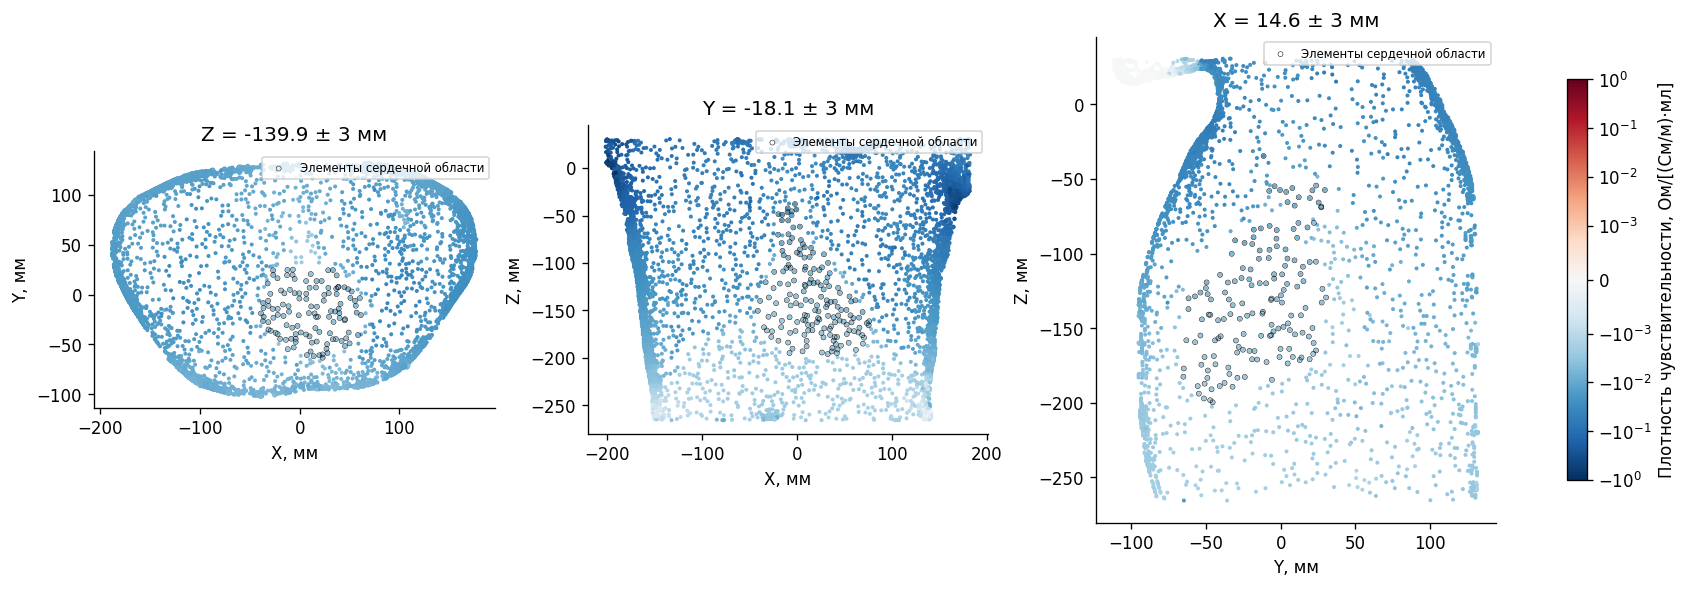

In [5]:
row=channels[channels.channel=='standard'].iloc[0]
stem=f'{row.montage}__{row.state}__standard'
with np.load(RUN/(stem+'_sensitivity.npz')) as f:density=f['density']/1e6
xyz=geometry['centroid_m']*1000
heart=geometry['tissue_id']==3
centre=np.average(xyz[heart],axis=0,weights=geometry['volume_m3'][heart])
fig,axes=plt.subplots(1,3,figsize=(14,4.7),constrained_layout=True)
for ax,(a,b,c) in zip(axes,[(0,1,2),(0,2,1),(1,2,0)]):
    ids=np.flatnonzero(abs(xyz[:,c]-centre[c])<=3)
    ids=ids[::max(1,int(np.ceil(len(ids)/35000)))]
    dots=ax.scatter(xyz[ids,a],xyz[ids,b],c=density[ids],s=2,cmap='RdBu_r',norm=SymLogNorm(linthresh=.001,vmin=-1,vmax=1))
    ax.set(xlabel='XYZ'[a]+', мм',ylabel='XYZ'[b]+', мм',title=f'{"XYZ"[c]} = {centre[c]:.1f} ± 3 мм')
    hid=ids[geometry['tissue_id'][ids]==3]
    ax.scatter(xyz[hid,a],xyz[hid,b],facecolors='none',edgecolors='black',s=9,linewidths=.3,label='Элементы сердечной области')
    ax.legend(fontsize=7,loc='upper right')
    ax.set_aspect('equal')
fig.colorbar(dots,ax=axes,label='Плотность чувствительности, Ом/[(См/м)·мл]',shrink=.82)
plt.show()

## 5. Локальные изменения равного эффективного объёма

Для проверки влияния размера области построены три технические пробы по 10 мл: в мягкотканном фоне, сердечной области и лёгких. Центр каждой пробы выбран детерминированно: ближайший центр элемента к объёмно-взвешенному центру соответствующей маски. Это правило воспроизводимости, а не выбор физиологического очага. Далее элементы выбираются по расстоянию их центров от заданного центра.

Для точного совпадения эффективных объёмов последнему элементу присваивается вес от 0 до 1. Вес равномерно уменьшает изменение проводимости в этом элементе; он не изображает точно вырезанную геометрическую часть тетраэдра. Поэтому отдельно приведены полный объём затронутых элементов и эффективный объём, равный сумме произведений объёмов на веса. Полученные области не обязательно являются шарами или строго связными анатомическими областями.

Во всех трёх пробах принят одинаковый технический масштаб изменения проводимости +0,001 См/м. Предсказанный отклик вычисляется как

$$\Delta Z\approx\Delta\sigma\sum_e a_eJ_e,$$

где $a_e$ — вес элемента, $\Delta\sigma$ — общий абсолютный масштаб изменения проводимости. 10 мл здесь означает эффективный объём электрического возмущения, а не объём перемещённой крови. Приведённые три положения являются демонстрацией метода; они не задают универсальный порядок чувствительности тканей.

Компартмент,"Эффективный объём, мл","Полный объём элементов, мл",Число элементов,Вес последнего элемента,"Линейный отклик, мОм"
Мягкотканный фон,10.000000,10.253956,29,0.086948,-0.044819
Сердечная область,10.000000,10.231670,24,0.405172,-0.037678
Лёгкие,10.000000,10.126784,27,0.768074,-0.172924


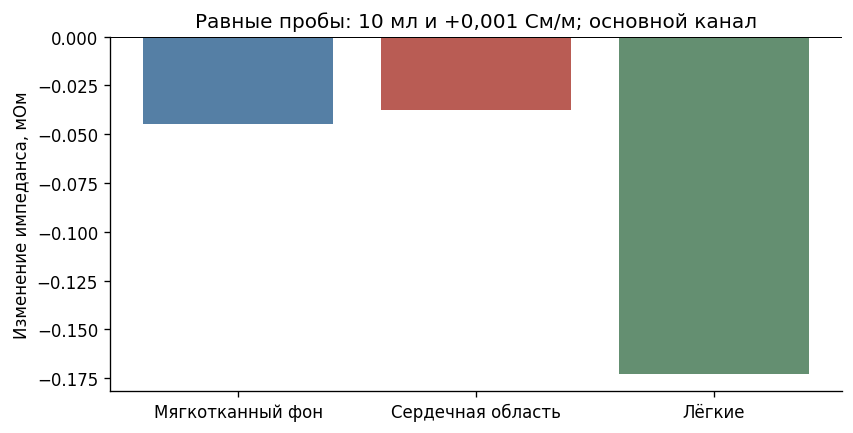

In [6]:
p=probes[probes.channel=='standard'].copy()
p['Компартмент']=p.tissue.map(labels)
p=p.rename(columns={'effective_volume_ml':'Эффективный объём, мл','support_volume_ml':'Полный объём элементов, мл','element_count':'Число элементов','terminal_weight':'Вес последнего элемента','predicted_delta_Z_mohm':'Линейный отклик, мОм'})
display(p[['Компартмент','Эффективный объём, мл','Полный объём элементов, мл','Число элементов','Вес последнего элемента','Линейный отклик, мОм']].style.hide(axis='index').format(precision=6))
fig,ax=plt.subplots(figsize=(7,3.5),constrained_layout=True)
ax.bar(p['Компартмент'],p['Линейный отклик, мОм'],color=['#557fa5','#b95c54','#648f71'])
ax.set(ylabel='Изменение импеданса, мОм',title='Равные пробы: 10 мл и +0,001 См/м; основной канал')
ax.axhline(0,color='black',lw=.6)
plt.show()

## 6. Прямая проверка локальной линейной аппроксимации

Для сердечной пробы независимо собрана матрица изменения проводимости из локальных матриц тетраэдров. Её билинейная форма сопоставлена с интегралом карты. Затем выполнены четыре новых прямых решения: изменения проводимости ±0,001 и ±0,0005 См/м при неизменных остальных параметрах.

Проверка центральной производной использует критерий абсолютного расхождения не более $10^{-5}+0{,}005|D|$ Ом/(См/м). Здесь $D$ — производная по абсолютному масштабу изменения проводимости локальной пробы. Это заранее заданный вычислительный допуск; он не характеризует погрешность физиологической модели. Односторонние отклики дополнительно сопоставляются с линейным предсказанием без замены прямых решений производной.

При очень малом изменении импеданса разность двух прямых решений чувствительна к численной погрешности; уменьшение шага не гарантирует монотонного улучшения оценки. Проверка относится к одной локальной сердечной пробе и основному каналу. Она не доказывает точность линейной аппроксимации для всех положений, амплитуд или исходных проводимостей.

In [7]:
f=fd.rename(columns={'delta_sigma_S_per_m':'Δσ, См/м','delta_Z_ohm':'Прямой ΔZ, Ом','linear_delta_Z_ohm':'Линейный ΔZ, Ом','linear_absolute_error_ohm':'Расхождение, Ом','relative_residual':'Относительная невязка'})
display(f[['Δσ, См/м','Прямой ΔZ, Ом','Линейный ΔZ, Ом','Расхождение, Ом','Относительная невязка']].style.hide(axis='index').format(precision=10))
local=verification[verification.check=='local_central_difference'].copy()
local['parameter']=local.parameter.str.rsplit('_',n=1).str[-1].astype(float)
local['passed']=local.passed.map({True:'Да',False:'Нет'})
display(local[['parameter','actual','reference','absolute_error','passed']].rename(columns={'parameter':'Модуль шага, См/м','actual':'Конечная разность, Ом/(См/м)','reference':'Производная, Ом/(См/м)','absolute_error':'Абсолютное расхождение, Ом/(См/м)','passed':'Критерий выполнен'}).style.hide(axis='index').format(precision=9))

"Δσ, См/м","Прямой ΔZ, Ом","Линейный ΔZ, Ом","Расхождение, Ом",Относительная невязка
-0.0010000000,0.0000377316,0.0000376783,0.0000000534,0.0000000002
0.0010000000,-0.0000376466,-0.0000376783,0.0000000317,0.0000000001
-0.0005000000,0.0000188454,0.0000188391,0.0000000063,0.0000000001
0.0005000000,-0.0000188519,-0.0000188391,0.0000000128,0.0000000001


"Модуль шага, См/м","Конечная разность, Ом/(См/м)","Производная, Ом/(См/м)","Абсолютное расхождение, Ом/(См/м)",Критерий выполнен
0.001000000,-0.037689127,-0.037678278,0.000010849,Да
0.000500000,-0.037697291,-0.037678278,0.000019012,Да


## 7. Новые комбинации ролей и независимость измерений

Три проверенные комбинации используют одни и те же физические контакты. Для симметричной линейной системы выполняется тождество

$$Z_{13,24}=Z_{14,23}+Z_{12,34},$$

где первая пара индексов указывает токовые электроды, вторая — измерительные; знак задаётся порядком индексов. Это тождество также выполняется для производных. Следовательно, три такие комбинации не образуют три независимых измерения: их алгебраическая размерность не превышает двух, а практическая информативность может быть ещё ниже.

Относительная нормировка на почти нулевой импеданс не используется. В программной реализации принят диагностический порог $10^{-8}$ Ом плюс $10^{-6}$ от максимального модуля импеданса каналов данного монтажа и состояния. Это правило устойчивости представления чисел, не модель шума прибора. Размерные производные и знаковые карты сохраняются и для такого канала.

In [8]:
c=channels.copy();c['Комбинация']=c.channel.map(channel_names)
c['relative_normalization_available']=c.relative_normalization_available.map({True:'Да',False:'Нет'})
display(c[['Комбинация','Z_ohm','reciprocity_absolute_ohm','relative_normalization_available','normalization_floor_ohm']].rename(columns={'Z_ohm':'Z, Ом','reciprocity_absolute_ohm':'Невязка взаимности, Ом','relative_normalization_available':'Относительная нормировка допустима','normalization_floor_ohm':'Порог нормировки, Ом'}).style.hide(axis='index').format(precision=10))
values={r.channel:r.Z_ohm for r in channels.itertuples()}
display(Markdown(f'Расхождение тождества трёх каналов: **{abs(values["cross"]-values["standard"]-values["adjacent"]):.3g} Ом**. Этот контроль относится к данной дискретной системе.'))

Комбинация,"Z, Ом","Невязка взаимности, Ом",Относительная нормировка допустима,"Порог нормировки, Ом"
Основная,189.2417046201,0.0000000226,Да,0.0001892517
Соседние пары,-0.0000004401,0.0000000000,Нет,0.0001892517
Перекрёстная,189.2417041823,0.0000000003,Да,0.0001892517


Расхождение тождества трёх каналов: **2.21e-09 Ом**. Этот контроль относится к данной дискретной системе.

## 8. Численные проверки и их границы

Ядро проверено на аналитических линейных полях, перестановке вершин, масштабировании и переносе координат, компенсации вкладов и разном размере пакетов обработки. Отдельный малый сетевой пример с шестью контактами проверяет составление правых частей и выбор каналов. Эти примеры проверяют код; они не заменяют анатомический эксперимент.

На полной модели проверены невязка, взаимность, совпадение сумм карт с матричными производными по всем четырём тканям, воспроизведение опорного результата 40.05 и локальная конечная разность. Поля первого контрольного прогона получены независимым итерационным решателем, многоканальный прогон выполнен PARDISO. Оба решают одну и ту же дискретную постановку соответствующего монтажа.

Сходимость по сетке, физическая корректность новых геометрий контактов, ошибки установки и контактного импеданса, а также соответствие реальному физиологическому событию остаются отдельными проверками. Наличие карты не повышает автоматически доказательный статус модели.

In [9]:
qc=verification.groupby('check',as_index=False).agg(Число=('passed','size'),Выполнены=('passed','all'),Максимальное_абсолютное_расхождение=('absolute_error','max'))
qc['Проверка']=qc['check'].map({'map_integral':'Интеграл карты и объёмная матрица','frozen_40_05_regression':'Сопоставление с 40.05','four_electrode_channel_identity':'Тождество каналов для поэлементных производных','local_matrix_vs_map':'Локальная матрица и карта','local_central_difference':'Центральная конечная разность'})
qc['Выполнены']=qc['Выполнены'].map({True:'Да',False:'Нет'})
display(qc[['Проверка','Число','Выполнены']].style.hide(axis='index'))

Проверка,Число,Выполнены
Тождество каналов для поэлементных производных,1,Да
Сопоставление с 40.05,4,Да
Центральная конечная разность,2,Да
Локальная матрица и карта,1,Да
Интеграл карты и объёмная матрица,12,Да


## 9. Что подготовлено для следующей серии

Реализованы отдельное описание монтажа и каналов, произвольное число контактов, список параметров с соответствующими объёмными блоками, исходные состояния, сохранение полей и пространственных карт. Реализован экспорт уже подготовленной модели EIDORS и включение нового расчёта в каноническую точку входа. Пример конфигурации с шестью условными электродами проверяет структуру; его заполнители контрольных сумм требуют замены реальными экспортированными входами.

Следующий анализ начинается с конкретной спецификации контактов: координат, формы, площади, контактного импеданса и списка физически присутствующих электродов. Затем задаются токовые и измерительные комбинации, компартменты, исходные проводимости и пространственные возмущения. Для новой геометрии проверяются фактические поверхности контактов и разрешение сетки. Использование прежних матриц разрешено только при совпадающей геометрии и нумерации узлов.

В первичном сравнении следует отдельно предъявлять интегральный отклик всего компартмента, среднюю плотность, расположение положительных и отрицательных областей и отклик выбранных локальных проб. После этого исследуются зависимость от исходного состояния и совместная различимость целевых и мешающих параметров. Для физиологического возмущения требуется отдельное обоснование его пространственного распределения и амплитуды.

## 10. Воспроизводимость и методический результат

- [План и журнал выполнения](40.06_Подготовка_анализа_новых_электродных_комбинаций.md).
- [Расчёт каналов и карт](../MATLAB_TRKG4_real_subjects/tools/run_electrode_sensitivity.py).
- [Ядро поэлементной чувствительности](../MATLAB_TRKG4_real_subjects/tools/compartment_sensitivity.py).
- [Описание исследования и его проверка](../MATLAB_TRKG4_real_subjects/tools/electrode_sensitivity_contract.py).
- [Локальные пробы](../MATLAB_TRKG4_real_subjects/tools/sensitivity_probes.py).
- [Проверки на полной модели](../MATLAB_TRKG4_real_subjects/tools/check_electrode_sensitivity_preparation.py).
- [Пример конфигурации](../MATLAB_TRKG4_real_subjects/configs/electrode_sensitivity_study.example.json).

Численные результаты карт и конечных возмущений вычислены до подготовки отчёта. Его ячейки читают сохранённые данные, проверяют контрольные суммы и формируют таблицы и рисунки. Повторный канонический прогон с окончательной версией кода дополнительно проверяет интерфейс и отказ от неустойчивой относительной нормировки; исходные карты и конечные разности имеют отдельные паспорта, сохраняющие происхождение каждого числа.

**Результат этапа подготовки:** проверен переход от интегральных производных к поэлементным картам и локальным возмущениям одинакового эффективного объёма. Реализовано независимое задание контактов и каналов. На проверочном наборе показано, что дополнительные комбинации ролей могут иметь почти нулевой отклик и алгебраическую зависимость. Это обосновывает необходимость оценивать самостоятельную информацию новых сборок, а не только их количество. Выбор оптимальной сборки и переход к функциям сердца в этой работе не выполнены.